In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "xx"
os.environ["KAGGLE_KEY"] = "xx"

In [3]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 13 file(s) under /src/
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/meta_learning/mamal.py -> /content/src/meta_learning/mamal.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/pretrained.py
src/utils/save.py -> /content/src/utils/save.py

 All files saved under /content/src/
Contents of /content/src/:
/con

In [4]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh    # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [5]:
# imports
%run /content/src/imports.py

Using device: cuda


## **Continual Learning - Replay Buffer**

In [6]:
preprocess_dataset(
    target_classes=cfg.SELECTED_CLASSES,
    output_root=cfg.EXEMPLAR_ROOT,
    max_samples=cfg.EXEMPLAR_LIMIT
)

preprocess_dataset(
    target_classes=cfg.TASK_1,
    output_root=cfg.SUBSET1_ROOT,
)

preprocess_dataset(
    target_classes=cfg.TASK_1,
    output_root=cfg.LIMITED_SUBSET1_ROOT,
    max_samples=cfg.EXEMPLAR_LIMIT,
    splits=["train"]
)

preprocess_dataset(
    target_classes=cfg.TASK_2,
    output_root=cfg.SUBSET2_ROOT,
)


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_exemplars
Classes: 10 | Limit: 5

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_exemplars

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_subset1
Classes: 3 | Limit: Full

Processing split: train



Processing split: val


...


Done! Dataset ready at: ./UCF101/processed_subset1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_limited_subset1
Classes: 3 | Limit: 5

Processing split: train



Done! Dataset ready at: ./UCF101/processed_limited_subset1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_subset2
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_subset2


In [7]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1

# The "Master Map"
class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12}


In [8]:

# Load the 20 exemplars per class we preprocessed earlier
old_exemplars_dataset = UCF101Clips(
    cfg.EXEMPLAR_ROOT + "/train",
    class_to_idx=class_to_idx
)
# Load the full 10 classes of Subset 1
new_classes_dataset = UCF101Clips(
    cfg.SUBSET1_ROOT + "/train",
    class_to_idx=class_to_idx
)

val_base = UCF101Clips(cfg.EXEMPLAR_ROOT + "/val", class_to_idx=class_to_idx)
val_sub1 = UCF101Clips(cfg.SUBSET1_ROOT + "/val", class_to_idx=class_to_idx) # Added missing definition for val_sub1

test_base = UCF101Clips(cfg.EXEMPLAR_ROOT + "/test", class_to_idx=class_to_idx)
test_sub1 = UCF101Clips(cfg.SUBSET1_ROOT + "/test", class_to_idx=class_to_idx)

# Combine old samples with new on
# continual_train_dataset = ConcatDataset([old_exemplars_dataset, new_classes_dataset])

train_loader_sub1 = torch.utils.data.DataLoader(
    new_classes_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# Create test loaders
test_loader_old = torch.utils.data.DataLoader(
    test_base,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
test_loader_sub1 = torch.utils.data.DataLoader(
    test_sub1,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# Create combined loader for testing
combined_loader_val = torch.utils.data.DataLoader(
    ConcatDataset([val_base, val_sub1]),
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
combined_loader_test = torch.utils.data.DataLoader(
    ConcatDataset([test_base, test_sub1]),
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

In [9]:
# Instantiate the replay buffer 
buffer = ReplayBuffer(max_size=500)

In [10]:
# Create a temporary loader just to fill the buffer
filler_loader = torch.utils.data.DataLoader(old_exemplars_dataset, batch_size=batch_size)

for x, y in filler_loader:
    # This fills the buffer with 20 samples per old class
    buffer.add_batch(x, y)

print(f"Buffer populated with {len(buffer.data)} old samples.")

Buffer populated with 50 old samples.


### Reharsal CL with simple Replay Buffer

In [11]:
# Instantiate student model
model = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
params = torch.load(cfg.RESNET50_PATH, map_location=device)
model.load_state_dict(params)

# Expand the teacher to match old classes + new classes
model = expand_classifier(model, len(ALL_CLASSES_LIST)).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


In [12]:
# Define the optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.REPLAY_LR
)

In [13]:
train_continual(
    model=model,
    teacher=None,
    train_loader=train_loader_sub1,  
    val_loader=combined_loader_val,
    replay_buffer=buffer,
    optimizer=optimizer,
    device=device,
    num_old_classes=len(cfg.SELECTED_CLASSES),
    lambda_distill=cfg.LAMBDA_DISTILL,
    epochs=cfg.REPLAY_EPOCHS,
    kd = False

)

Epoch 1/5 | Train Loss: 31.7677 | Val Loss: 10.1991 | Val Acc: 0.9395
Epoch 2/5 | Train Loss: 6.3804 | Val Loss: 9.3982 | Val Acc: 0.8930
Epoch 3/5 | Train Loss: 2.1204 | Val Loss: 9.5564 | Val Acc: 0.8837
Epoch 4/5 | Train Loss: 1.2256 | Val Loss: 9.4765 | Val Acc: 0.8791
Epoch 5/5 | Train Loss: 1.1316 | Val Loss: 10.4875 | Val Acc: 0.8837


In [14]:
# Evaluate the model over all tasks (only old classes, only new classes, both)
_ = evaluate_all_tasks(
    model=model,
    device=device,
    base_loader=test_loader_old,
    task_loaders=[test_loader_sub1],
    combined_loaders=[combined_loader_test]
)

  base             -> Acc=0.8713  Loss=0.4609
  task1_only       -> Acc=0.9623  Loss=0.0945
  combined_t1      -> Acc=0.8929  Loss=0.3742


In [15]:
_, all_preds, all_labels = test_model(model, combined_loader_test, device)

print_detailed_metrics(
    all_labels=all_labels,
    all_preds=all_preds,
    num_classes=len(ALL_CLASSES_LIST),
    classes_list=ALL_CLASSES_LIST,
    split_old=(0, len(cfg.SELECTED_CLASSES)),
    split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST))
)

Running Inference on Test Set...


Test Accuracy: 0.8929

METRICS FOR 13 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.8929
  Precision : 0.9316
  Recall    : 0.8929
  F1-Score  : 0.8803

PER-CLASS REPORT 
                precision    recall  f1-score   support

  PlayingTabla       1.00      0.93      0.96        14
   PommelHorse       1.00      0.94      0.97        16
   JumpingJack       1.00      0.12      0.22        16
       PushUps       1.00      1.00      1.00        13
     PoleVault       0.82      0.95      0.88        19
     HorseRace       1.00      1.00      1.00        16
      HighJump       1.00      0.81      0.90        16
      Drumming       1.00      1.00      1.00        21
   HorseRiding       1.00      0.95      0.98        21
        Diving       1.00      0.95      0.97        19
ApplyEyeMakeup       0.90      0.95      0.92        19
 ApplyLipstick       0.93      0.93      0.93        15
       Archery       0.53      1.00      0.69        19

      accuracy                        

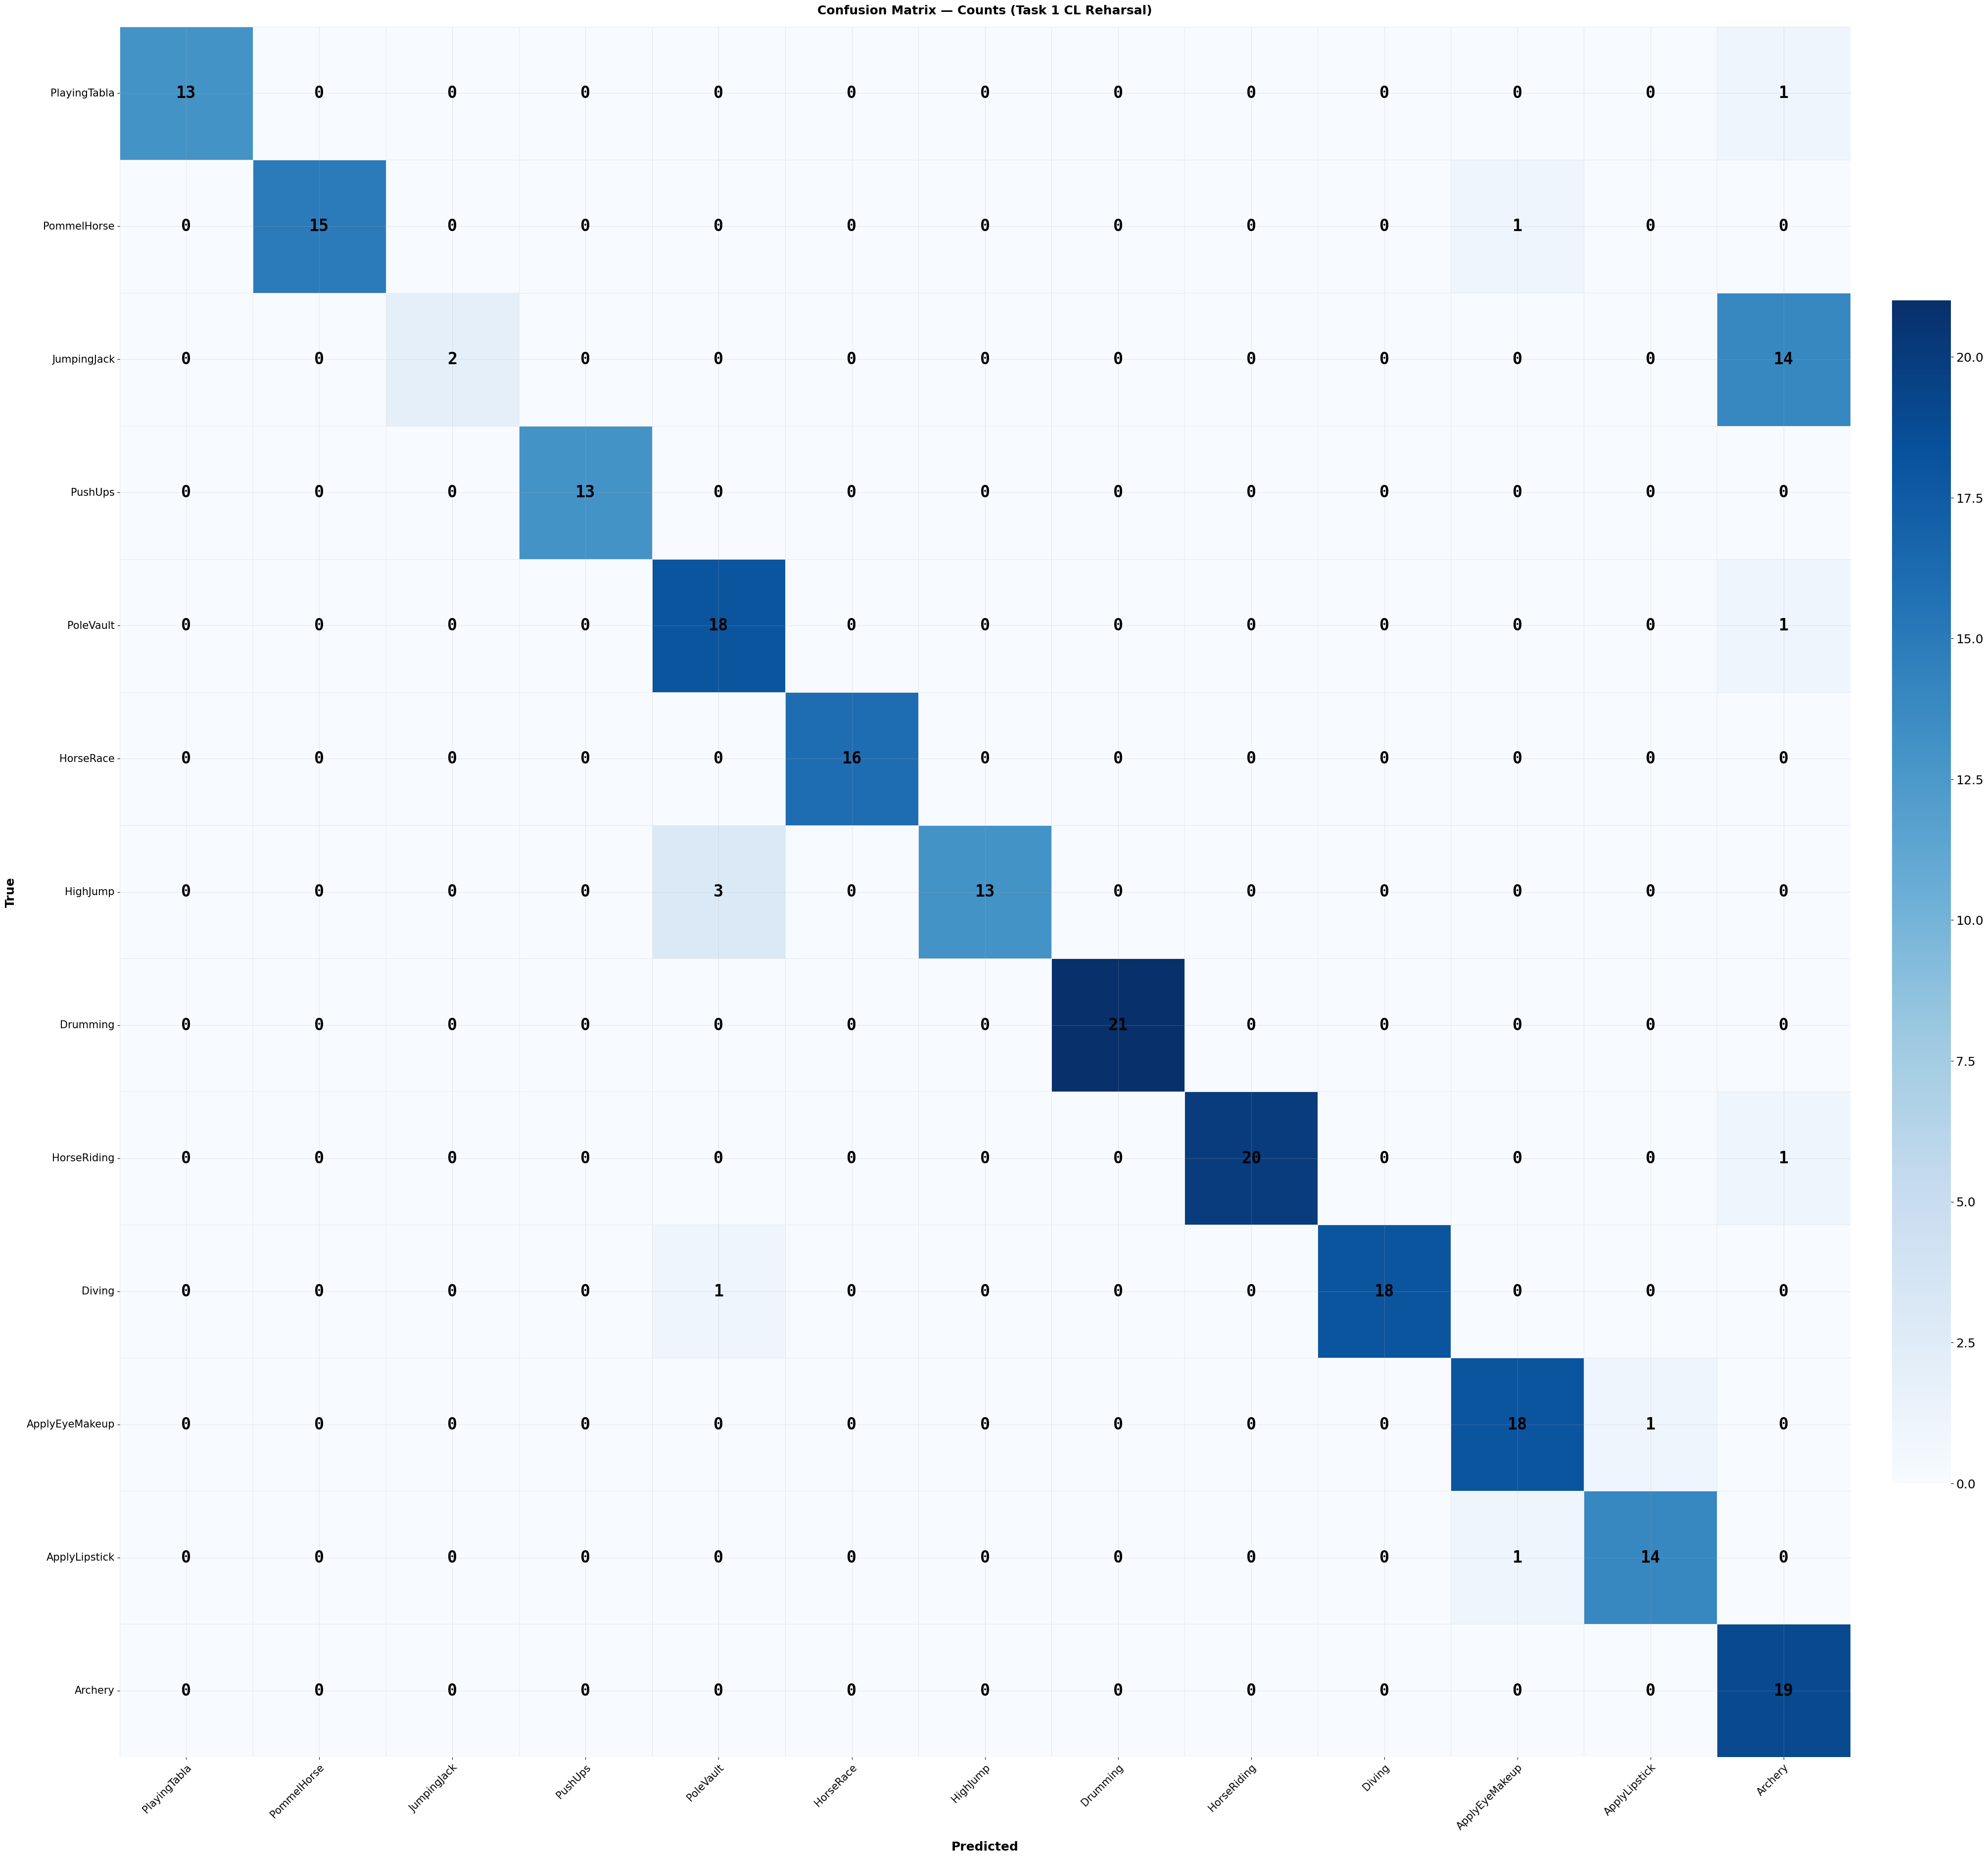

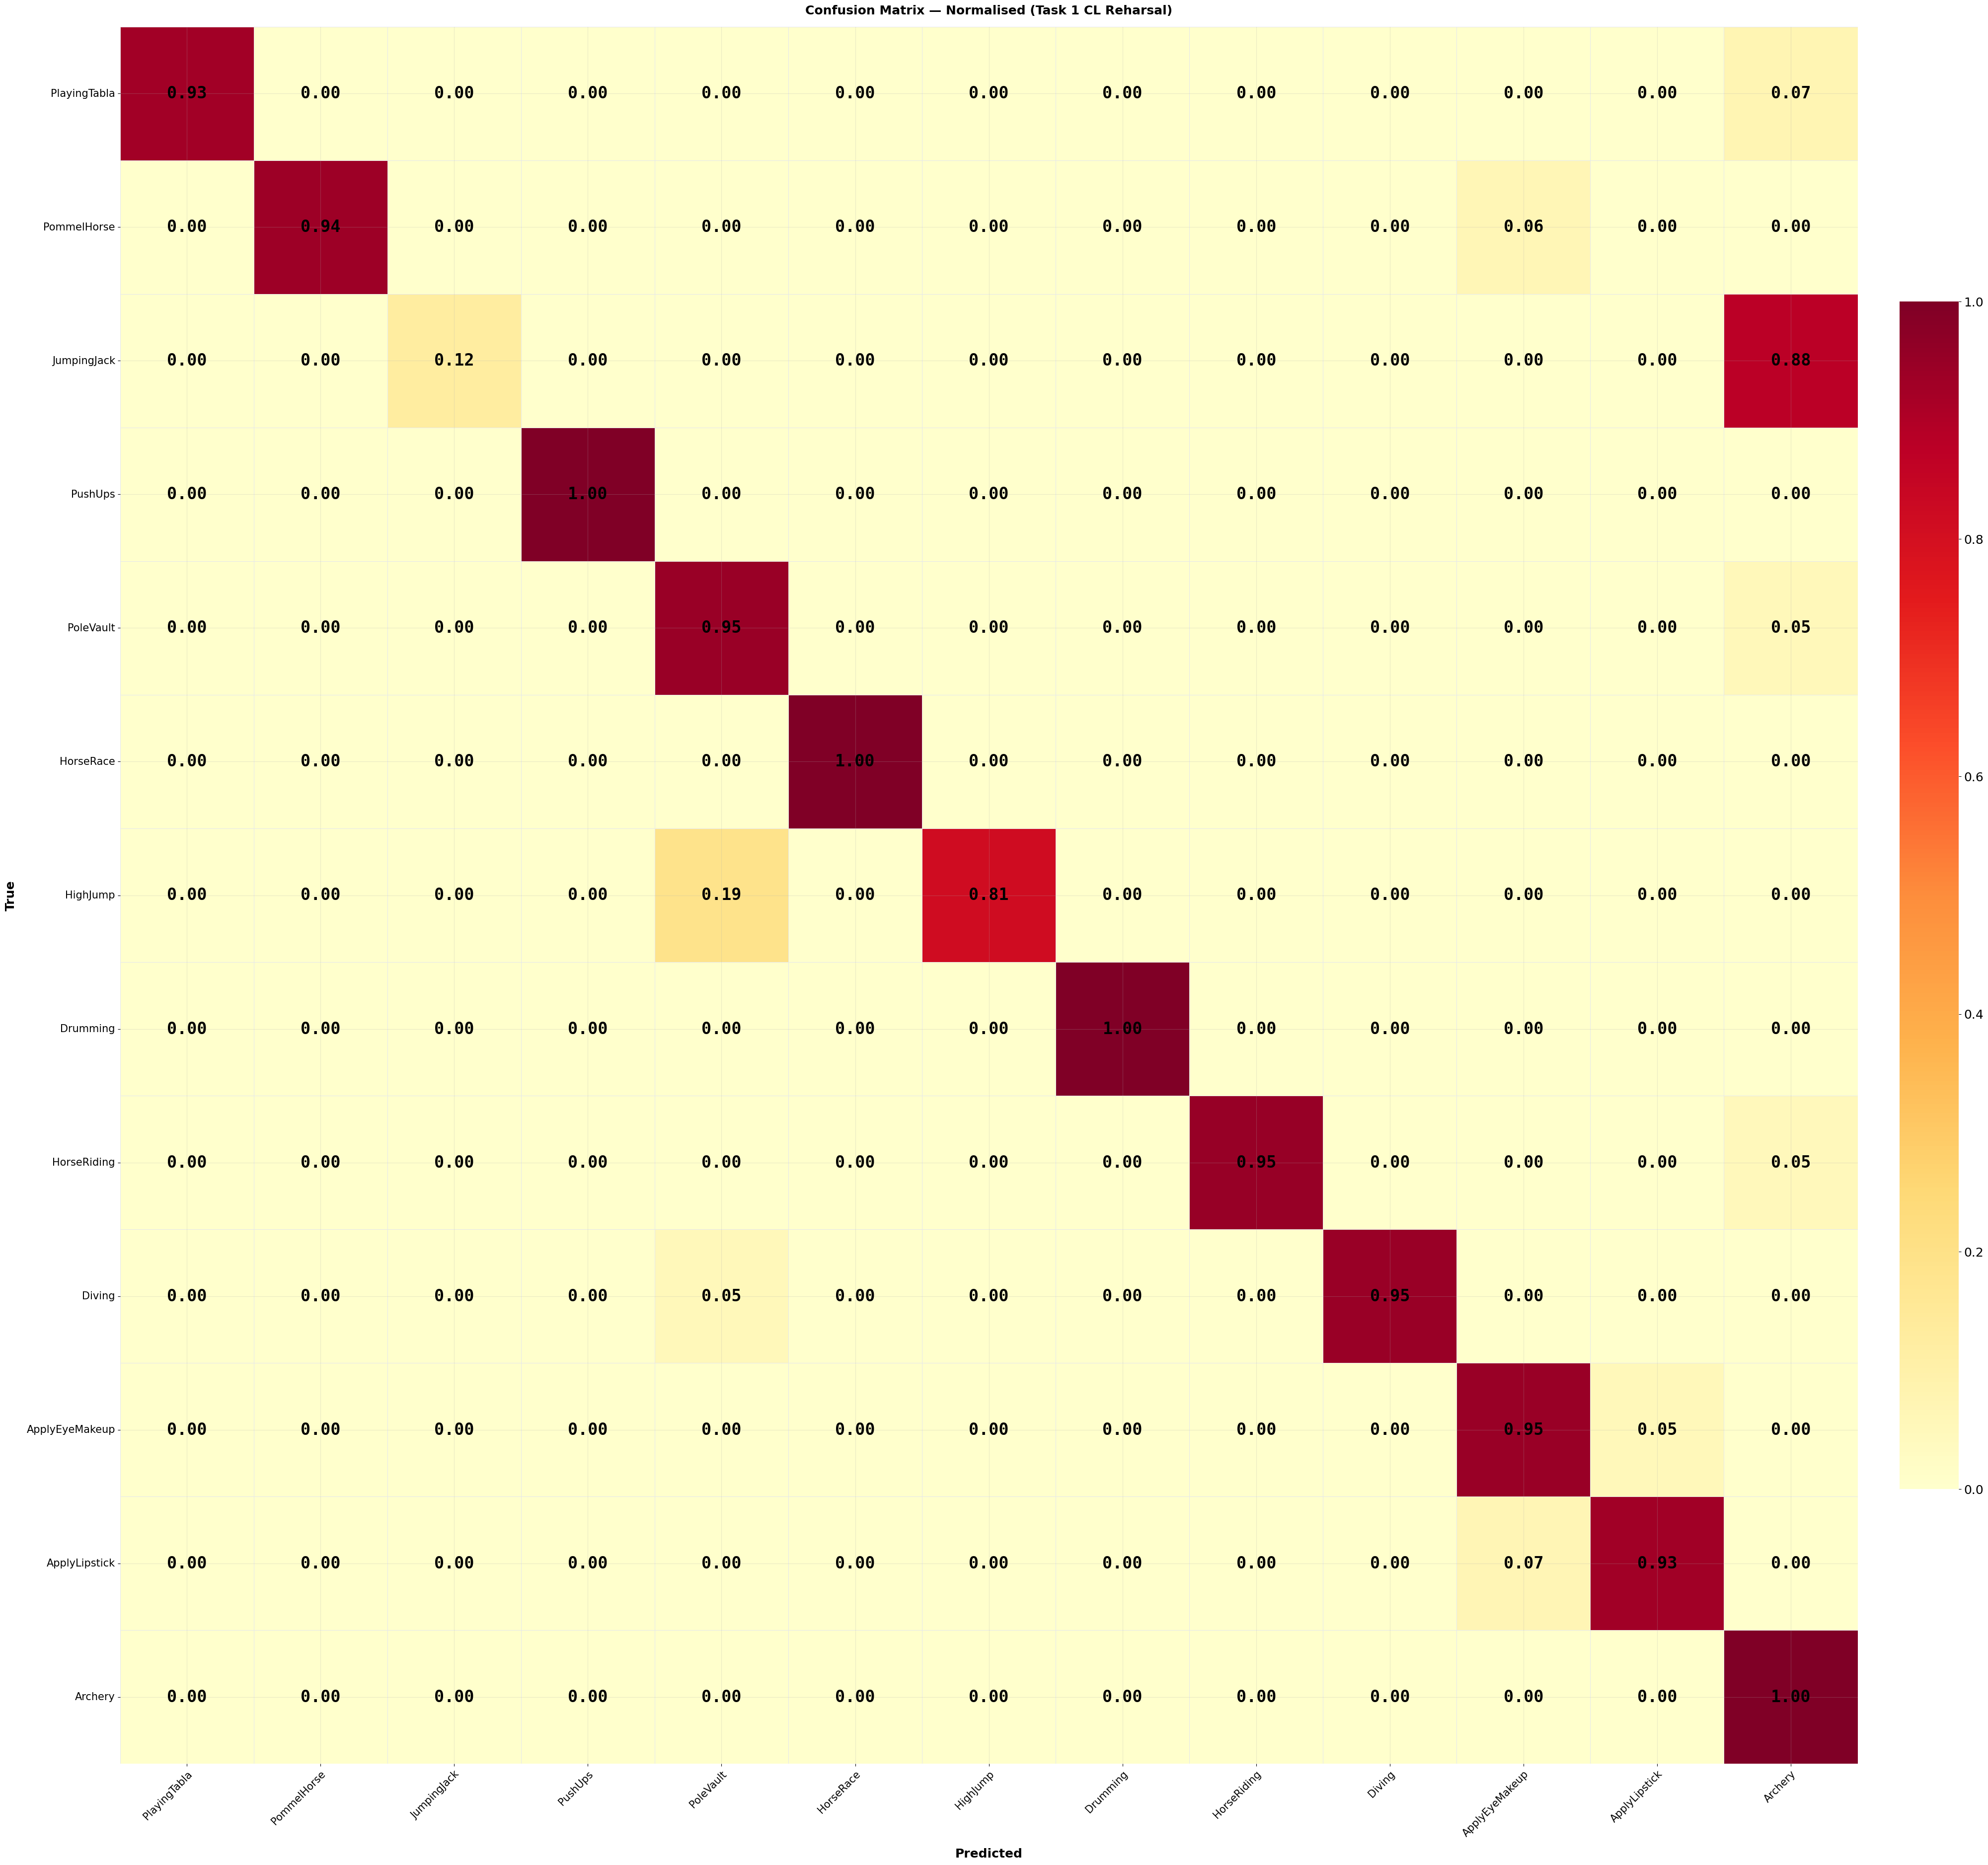

In [16]:
plot_confusion_matrix(all_labels, all_preds, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="Task 1 CL Reharsal")

#### Subset 2

In [17]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

# Global mapping
class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BoxingPunchingBag': 13, 'BoxingSpeedBag': 14, 'BrushingTeeth': 15}


In [18]:
# Load subset2 datasets and limited subset1
train_limited_sub1 = UCF101Clips(
    cfg.LIMITED_cfg.SUBSET1_ROOT + "/train",
    class_to_idx=class_to_idx
)

train_sub2 = UCF101Clips(
    cfg.SUBSET2_ROOT + "/train",
    class_to_idx=class_to_idx
)

val_sub2 = UCF101Clips(cfg.SUBSET2_ROOT + "/val", class_to_idx=class_to_idx)
 
test_sub2 = UCF101Clips(cfg.SUBSET2_ROOT + "/test", class_to_idx=class_to_idx)

train_loader_sub2 = torch.utils.data.DataLoader(
    train_sub2,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader_sub2 = torch.utils.data.DataLoader(
    test_sub2,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# Create combined loader for validation and testing
combined_val_loader = torch.utils.data.DataLoader(
    ConcatDataset([val_base, val_sub1, val_sub2]),
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
combined_test_loader = torch.utils.data.DataLoader(
    ConcatDataset([test_base, test_sub1, val_sub2]),
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

In [19]:
# Add samples from subset1 to the memory buffer (only 20 samples per class)
filler_loader = torch.utils.data.DataLoader(train_limited_sub1, batch_size=batch_size)

for x, y in filler_loader:
    # This fills the buffer with 20 samples per old class
    buffer.add_batch(x, y)

print(f"Buffer populated with {len(buffer.data)} old samples.")

Buffer populated with 65 old samples.


In [20]:
# Expand the model to match old classes + new classes
model = expand_classifier(model, len(ALL_CLASSES_LIST)).to(device)

In [21]:
# Define the optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.REPLAY_LR
)

In [22]:
train_continual(
    model=model,
    teacher=None,
    train_loader=train_loader_sub2, 
    val_loader = combined_val_loader,
    replay_buffer=buffer,
    optimizer=optimizer,
    device=device,
    num_old_classes=len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    lambda_distill=None,
    epochs=cfg.REPLAY_EPOCHS,
    kd = False
)

Epoch 1/5 | Train Loss: 42.4969 | Val Loss: 25.7857 | Val Acc: 0.7873
Epoch 2/5 | Train Loss: 9.6302 | Val Loss: 22.8170 | Val Acc: 0.8022
Epoch 3/5 | Train Loss: 3.1144 | Val Loss: 25.4043 | Val Acc: 0.7799
Epoch 4/5 | Train Loss: 1.5428 | Val Loss: 25.8967 | Val Acc: 0.7985
Epoch 5/5 | Train Loss: 1.0022 | Val Loss: 26.6913 | Val Acc: 0.7724


In [23]:
# Evaluate the model over all tasks (only old classes, only new classes, both)
_ = evaluate_all_tasks(
    model=model,
    device=device,
    base_loader=test_loader_old,
    task_loaders=[test_loader_sub1, test_loader_sub2],
    combined_loaders=[combined_test_loader]
)

  base             -> Acc=0.8480  Loss=0.5830
  task1_only       -> Acc=0.5472  Loss=1.6469
  task2_only       -> Acc=0.9818  Loss=0.0504
  combined_t1      -> Acc=0.8195  Loss=0.6791


In [24]:
_, all_preds_sub2, all_labels_sub2 = test_model(model, combined_test_loader, device)

'''
print_detailed_metrics(
    all_labels=all_labels,
    all_preds=all_preds,
    num_classes=len(ALL_CLASSES_LIST),
    classes_list=ALL_CLASSES_LIST,
    split_old=(0, len(cfg.SELECTED_CLASSES)),
    split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST))
)
'''

Running Inference on Test Set...


Test Accuracy: 0.8195


'\nprint_detailed_metrics(\n    all_labels=all_labels,\n    all_preds=all_preds,\n    num_classes=len(ALL_CLASSES_LIST),\n    classes_list=ALL_CLASSES_LIST,\n    split_old=(0, len(cfg.SELECTED_CLASSES)),\n    split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST))\n)\n'

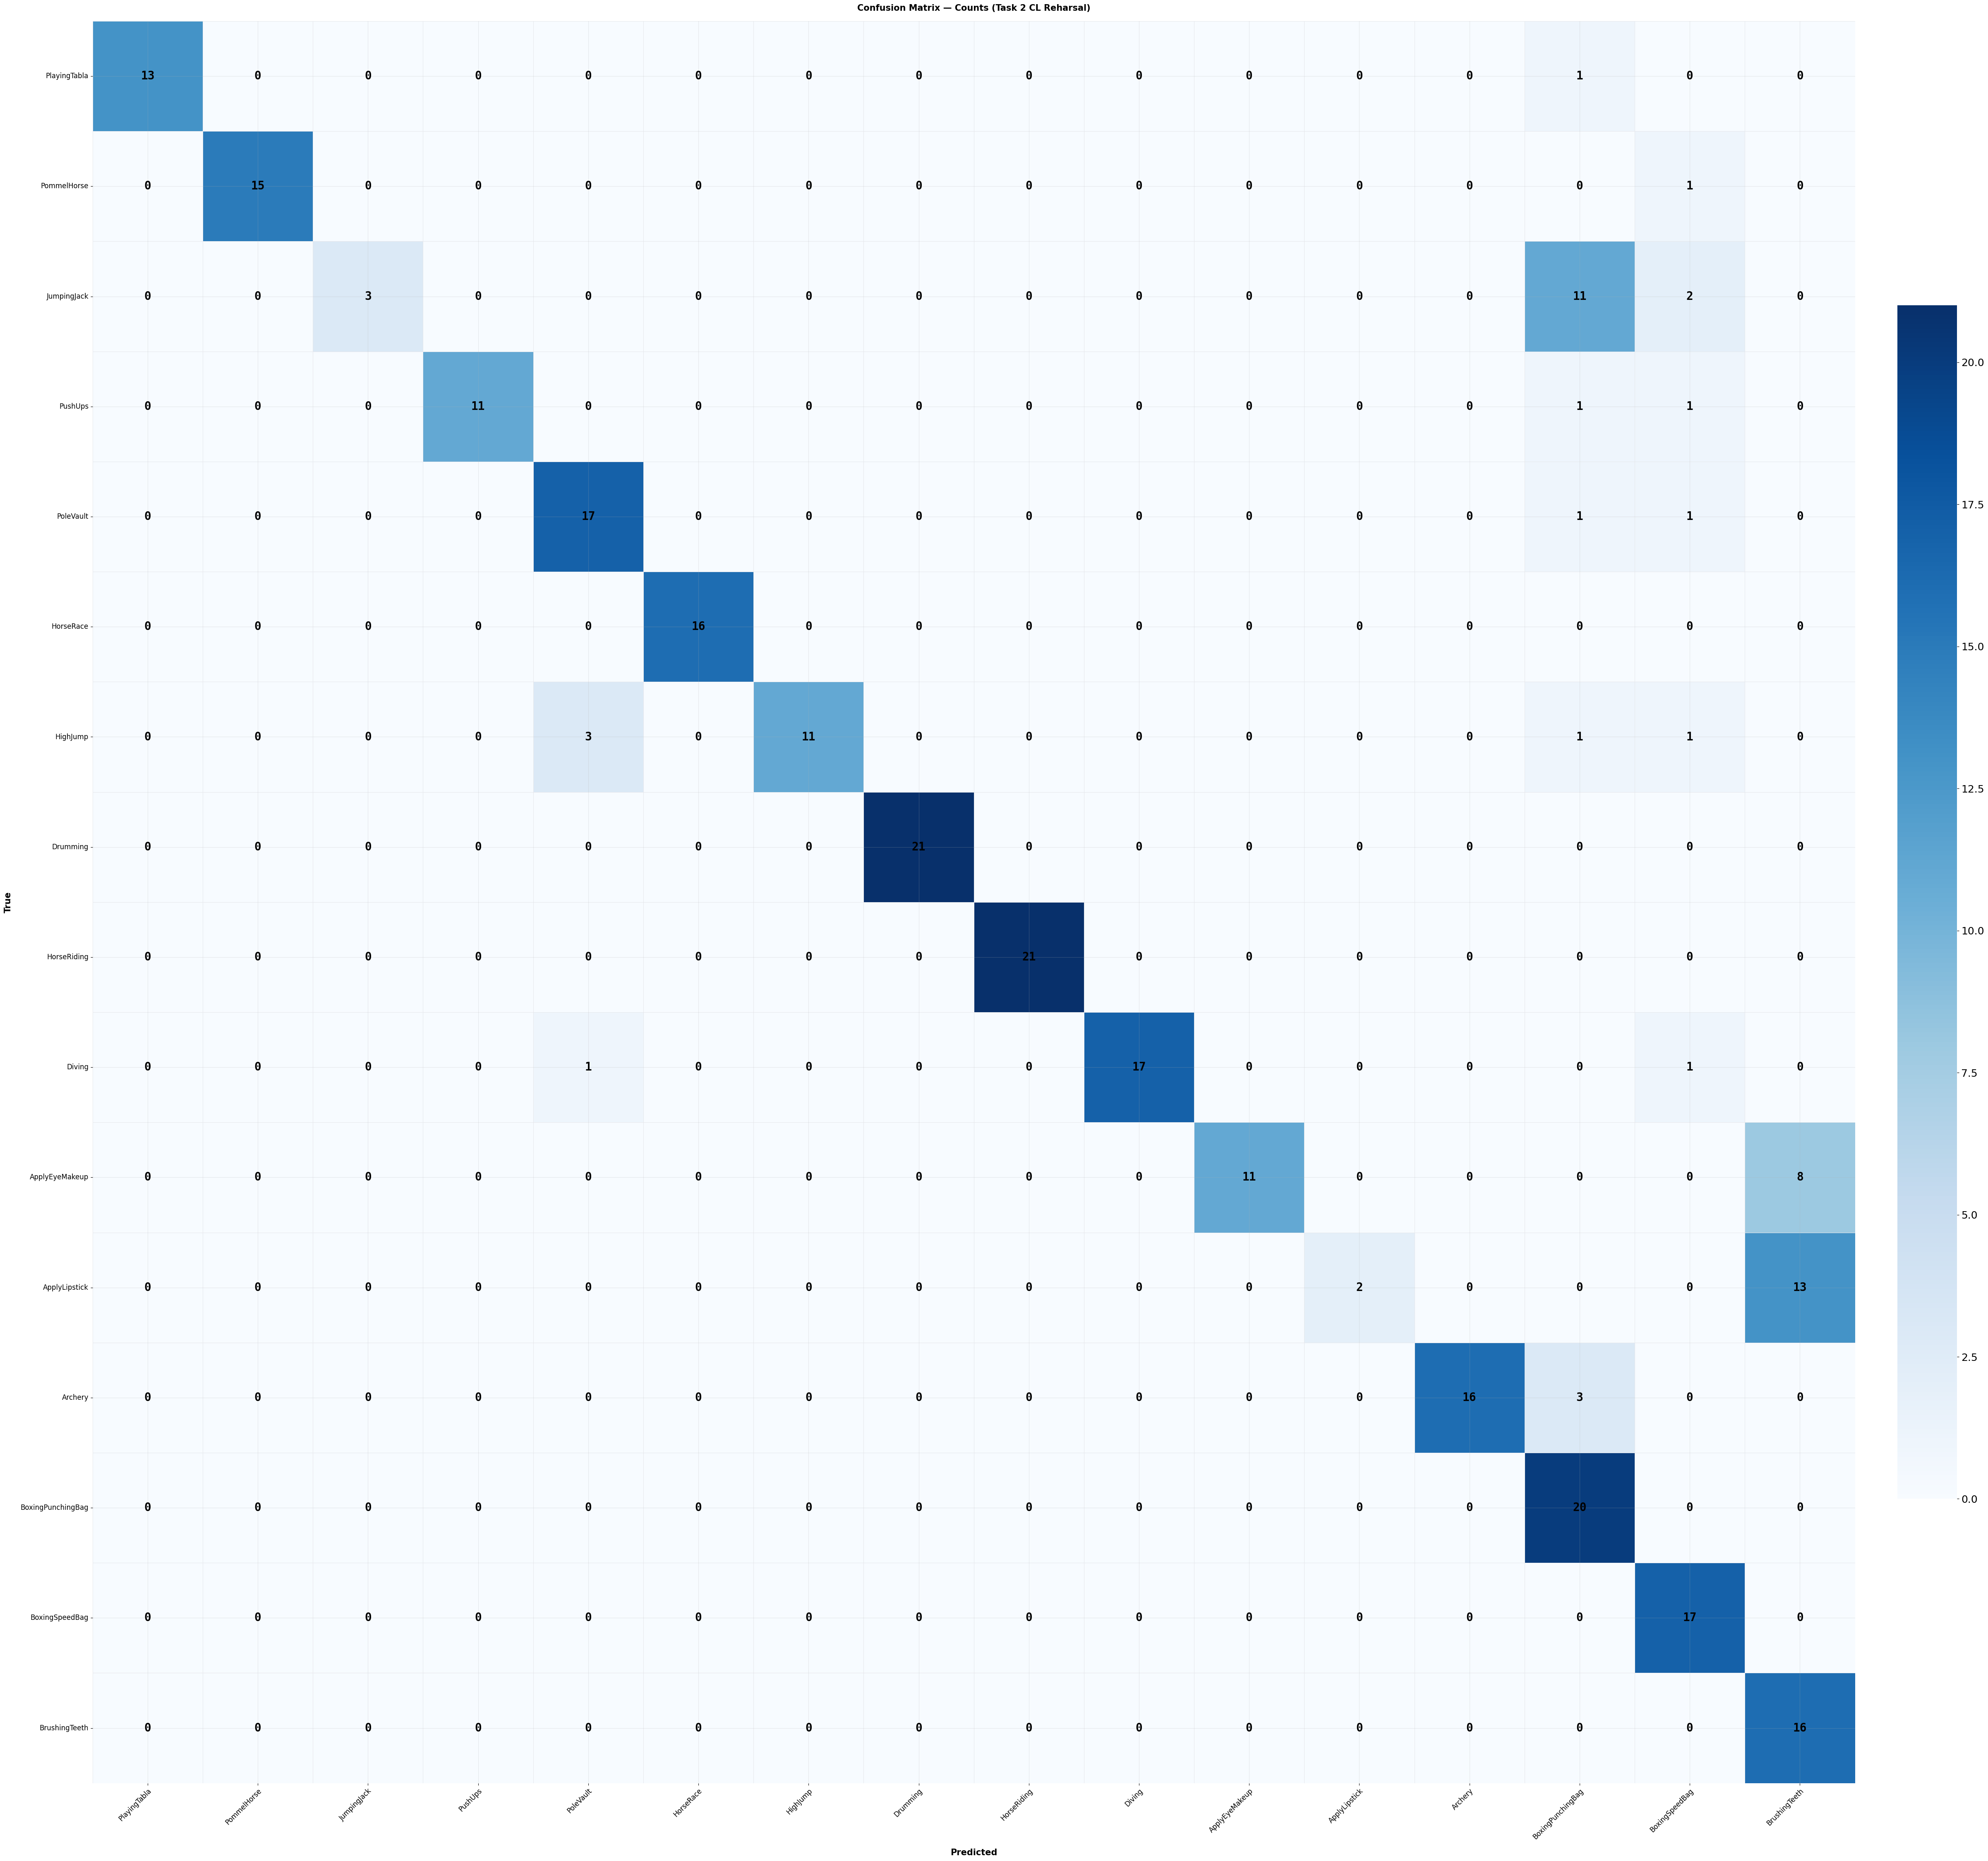

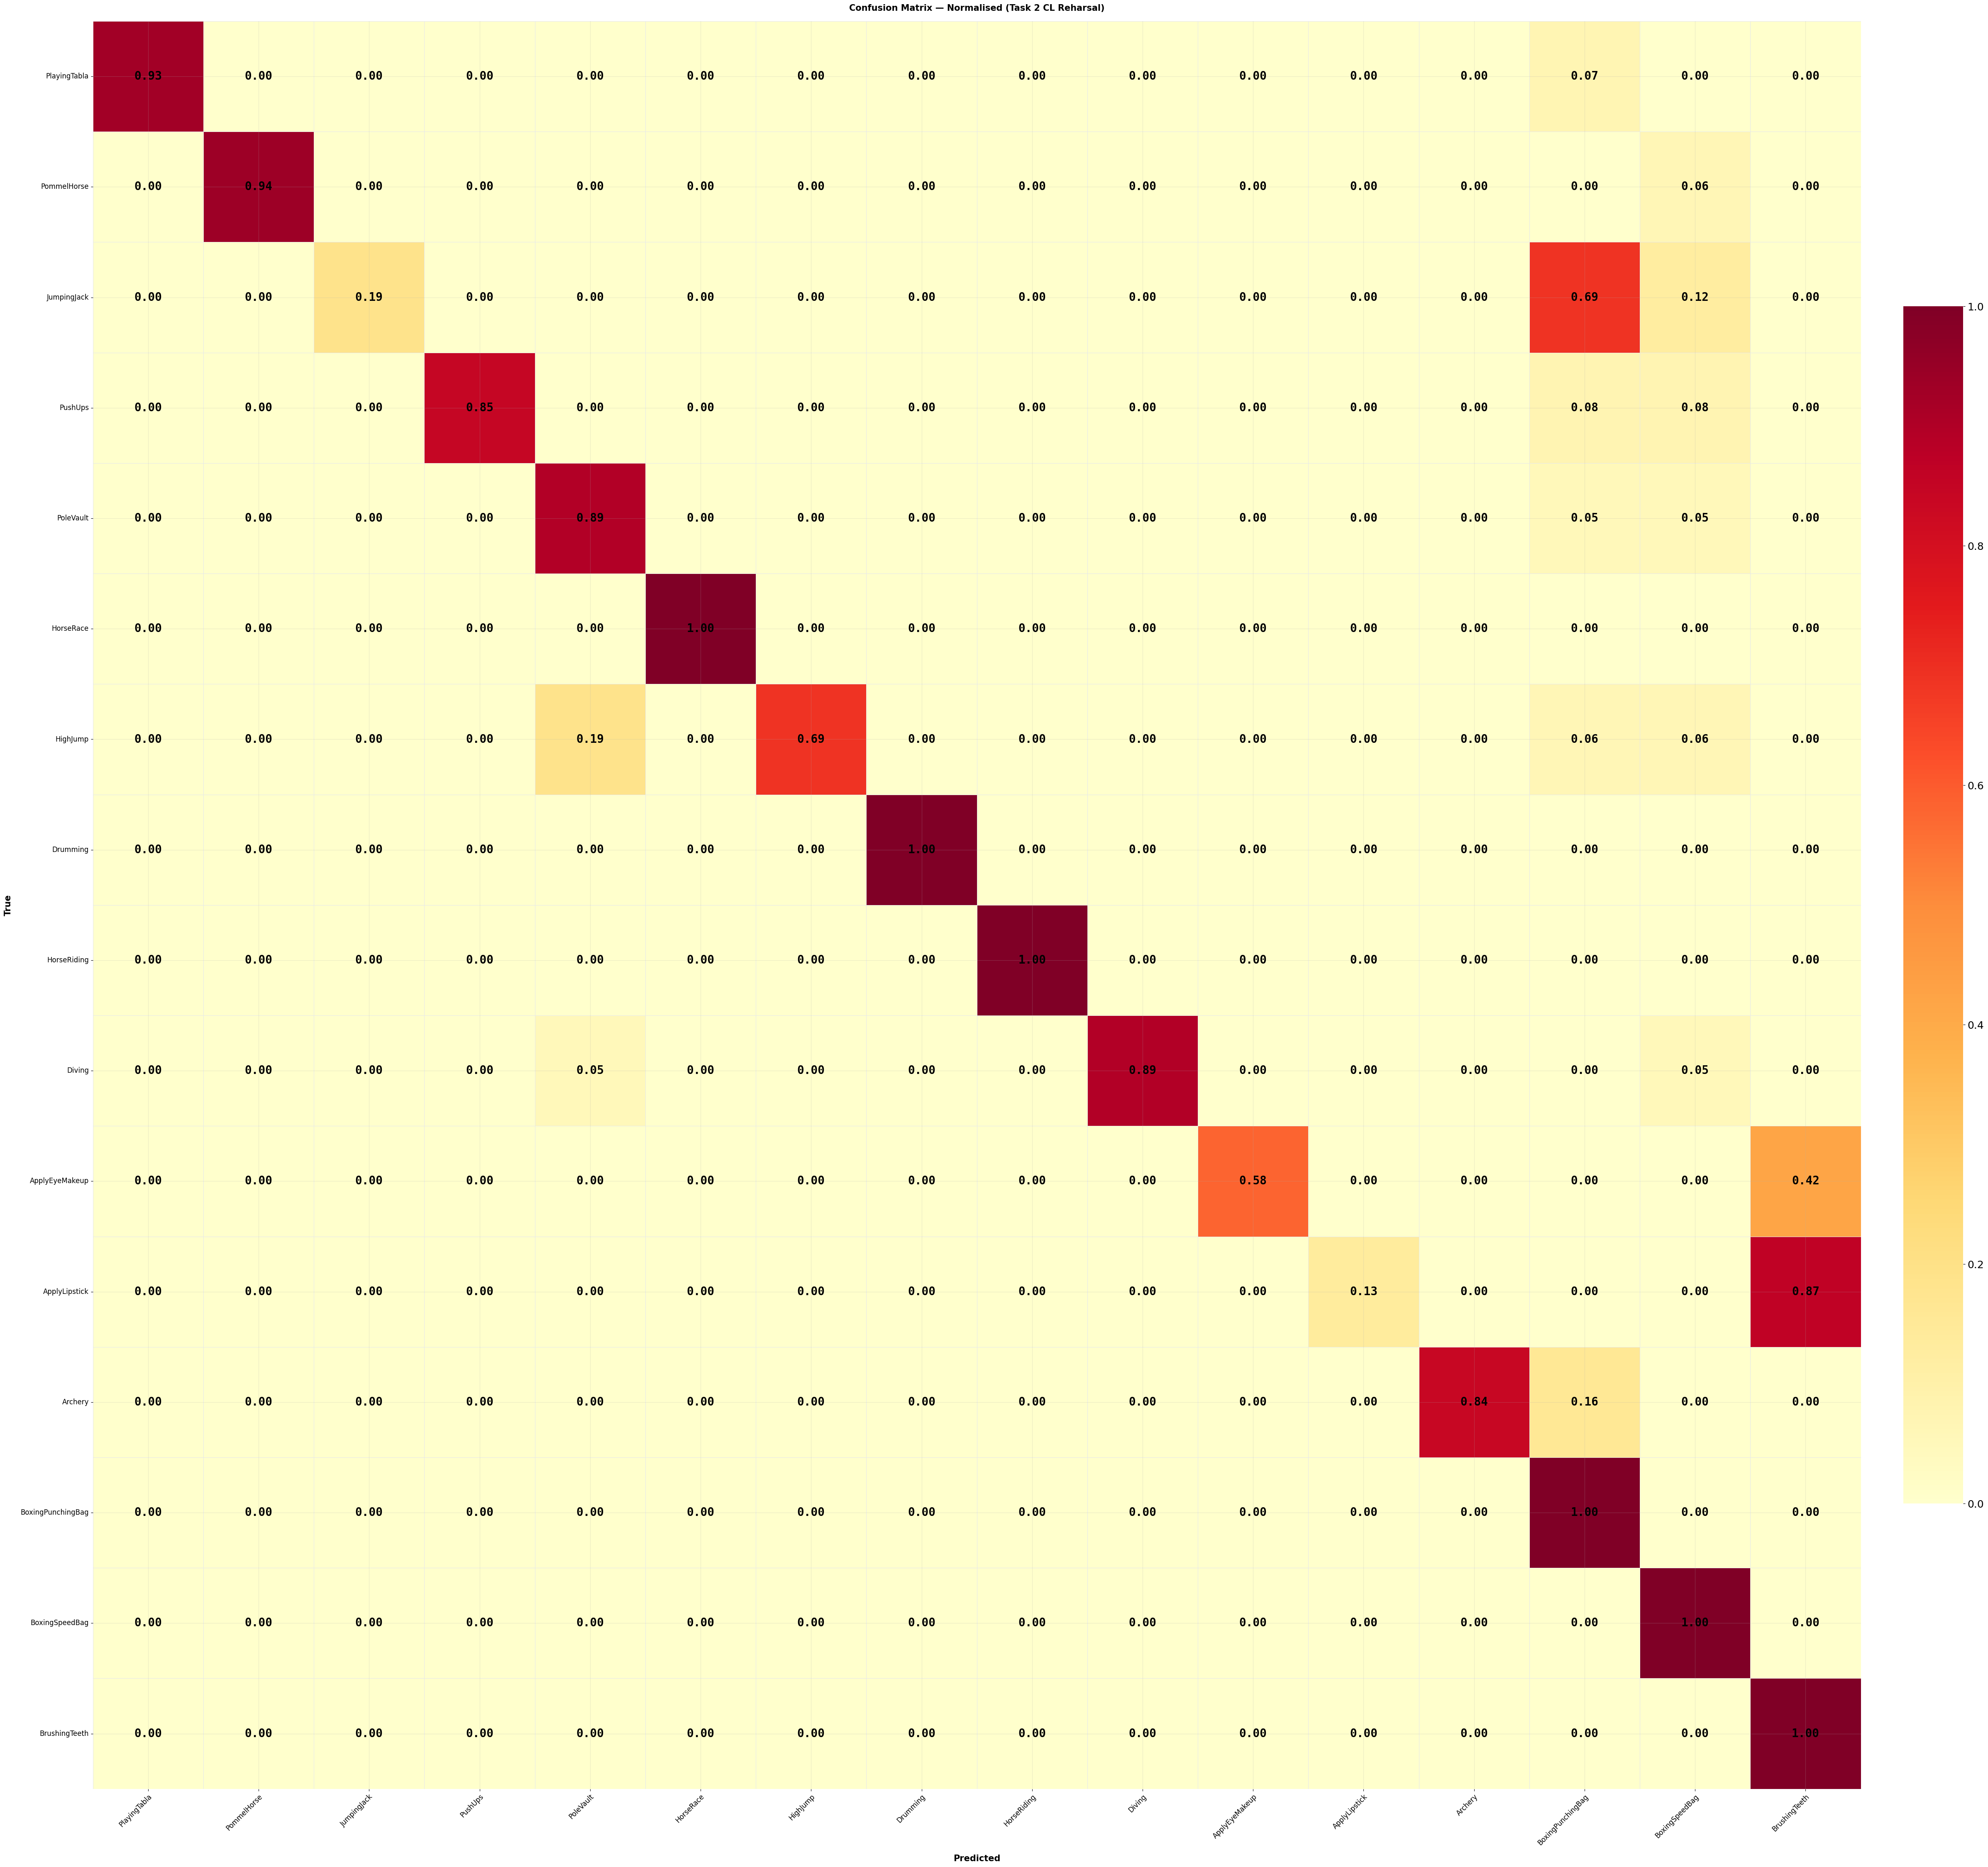

In [25]:
plot_confusion_matrix(all_labels_sub2, all_preds_sub2, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="Task 2 CL Reharsal")

### Reharsal CL with Replay Buffer + Knowledge Distillation Mechanism

In [26]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1

# Global mapping
class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12}


In [27]:
# Re-initialize the buffer only on subset 1
buffer = ReplayBuffer(max_size=500)

# Add samples from subset1 to the memory buffer (only 20 samples per class)
filler_loader = torch.utils.data.DataLoader(old_exemplars_dataset, batch_size=batch_size)

for x, y in filler_loader:
    # This fills the buffer with 20 samples per old class
    buffer.add_batch(x, y)

print(f"Buffer populated with {len(buffer.data)} old samples.")

Buffer populated with 50 old samples.


In [28]:
# Define teacher model
teacher = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
params = torch.load(cfg.RESNET50_PATH, map_location=device)
teacher.load_state_dict(params)

# Expand the teacher to match old classes + new classes
teacher = expand_classifier(teacher, len(ALL_CLASSES_LIST)).to(device)

In [29]:
# Instantiate student model
student = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
params = torch.load(cfg.RESNET50_PATH, map_location=device)
student.load_state_dict(params)

# Expand the teacher to match old classes + new classes
student = expand_classifier(student, len(ALL_CLASSES_LIST)).to(device)

In [30]:
# Define the optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, student.parameters()),
    lr=cfg.REPLAY_LR
)

train_continual(
    model=student,
    teacher=teacher,
    train_loader=train_loader_sub1,  # new classes loader
    val_loader=combined_loader_val,
    replay_buffer=buffer,
    optimizer=optimizer,
    device=device,
    num_old_classes=len(cfg.SELECTED_CLASSES),
    lambda_distill=cfg.LAMBDA_DISTILL,
    epochs=cfg.REPLAY_EPOCHS,
    kd = True
)

Epoch 1/3 | Train Loss: 51.7068 | Val Loss: 9.9030 | Val Acc: 0.9302
Epoch 2/3 | Train Loss: 30.8760 | Val Loss: 8.6009 | Val Acc: 0.9349
Epoch 3/3 | Train Loss: 25.4411 | Val Loss: 8.4791 | Val Acc: 0.9302


In [31]:
# Evaluate the model over all tasks (only old classes, only new classes, both)
_ = evaluate_all_tasks(
    model=student,
    device=device,
    base_loader=test_loader_old,
    task_loaders=[test_loader_sub1],
    combined_loaders=[combined_loader_test]
)

  base             -> Acc=0.9298  Loss=0.3595
  task1_only       -> Acc=1.0000  Loss=0.1602
  combined_t1      -> Acc=0.9464  Loss=0.3123


In [32]:
_, all_preds_kd, all_labels_kd = test_model(student, combined_loader_test, device)

print_detailed_metrics(
    all_labels=all_labels_kd,
    all_preds=all_preds_kd,
    num_classes=len(ALL_CLASSES_LIST),
    classes_list=ALL_CLASSES_LIST,
    split_old=(0, len(cfg.SELECTED_CLASSES)),
    split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST))
)

Running Inference on Test Set...


Test Accuracy: 0.9464

METRICS FOR 13 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9464
  Precision : 0.9512
  Recall    : 0.9464
  F1-Score  : 0.9469

PER-CLASS REPORT 
                precision    recall  f1-score   support

  PlayingTabla       1.00      0.93      0.96        14
   PommelHorse       1.00      1.00      1.00        16
   JumpingJack       1.00      0.81      0.90        16
       PushUps       1.00      1.00      1.00        13
     PoleVault       0.81      0.89      0.85        19
     HorseRace       1.00      1.00      1.00        16
      HighJump       0.81      0.81      0.81        16
      Drumming       1.00      1.00      1.00        21
   HorseRiding       1.00      0.90      0.95        21
        Diving       0.95      0.95      0.95        19
ApplyEyeMakeup       1.00      1.00      1.00        19
 ApplyLipstick       1.00      1.00      1.00        15
       Archery       0.83      1.00      0.90        19

      accuracy                        

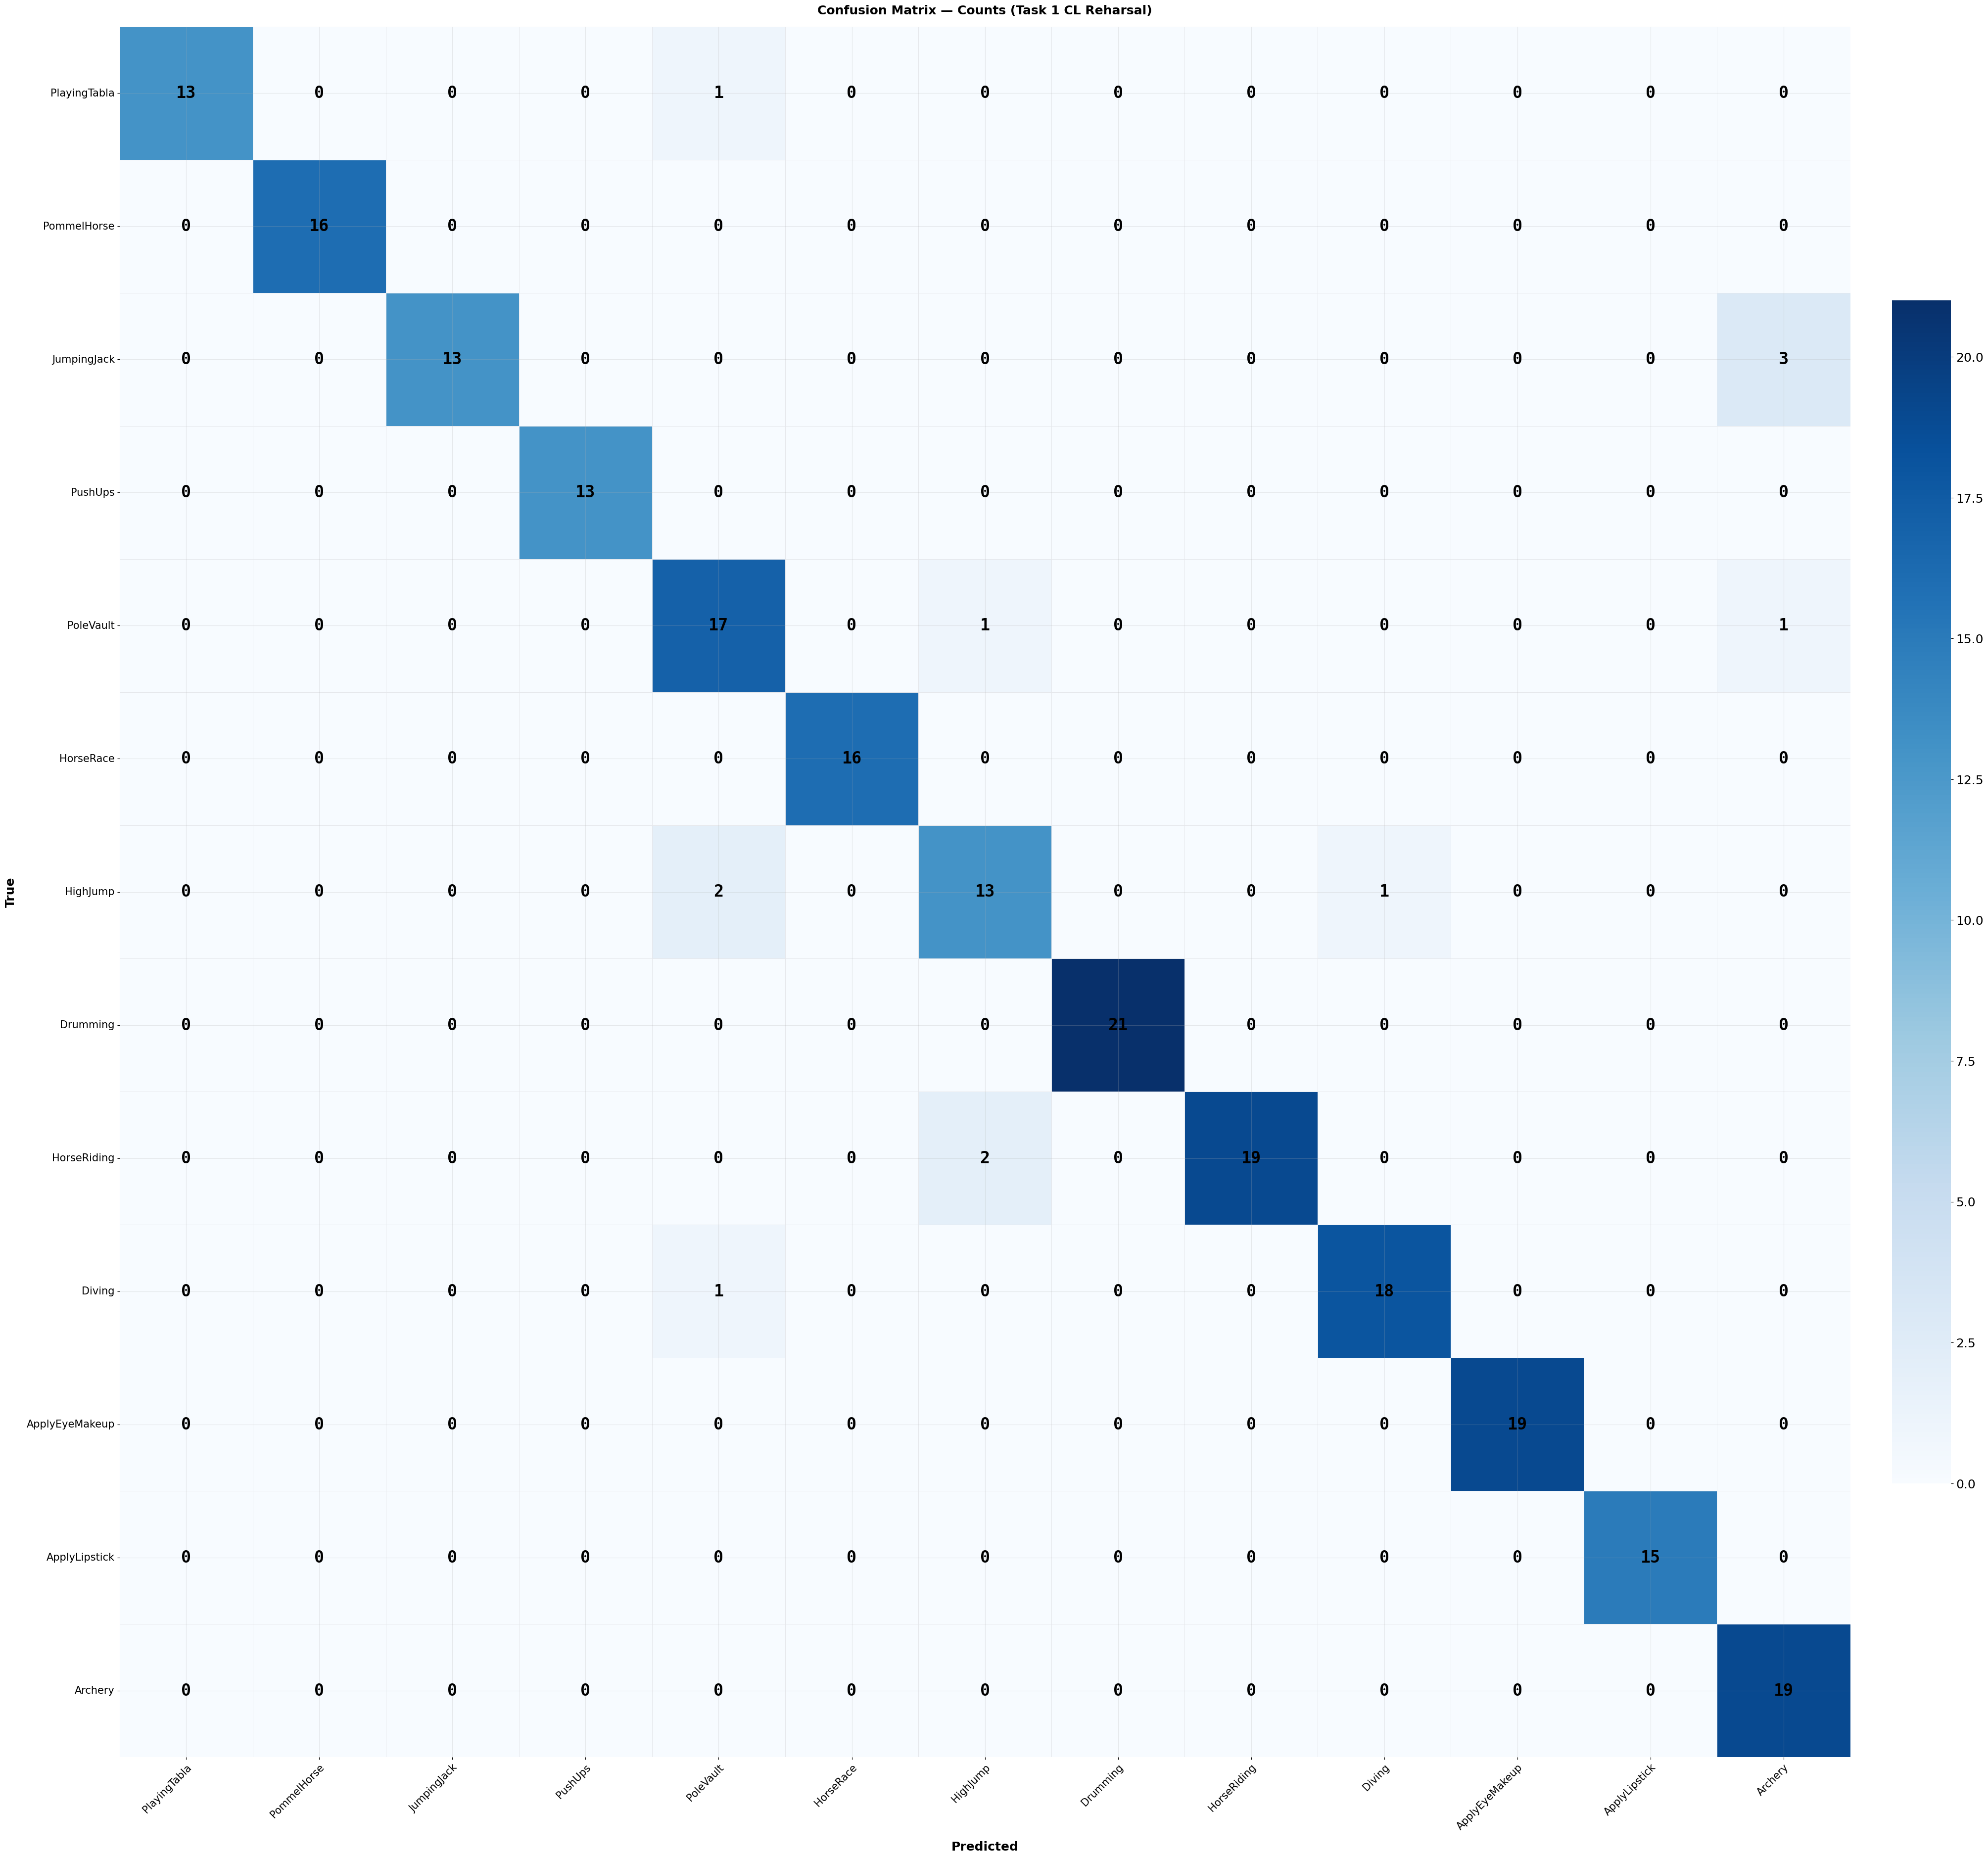

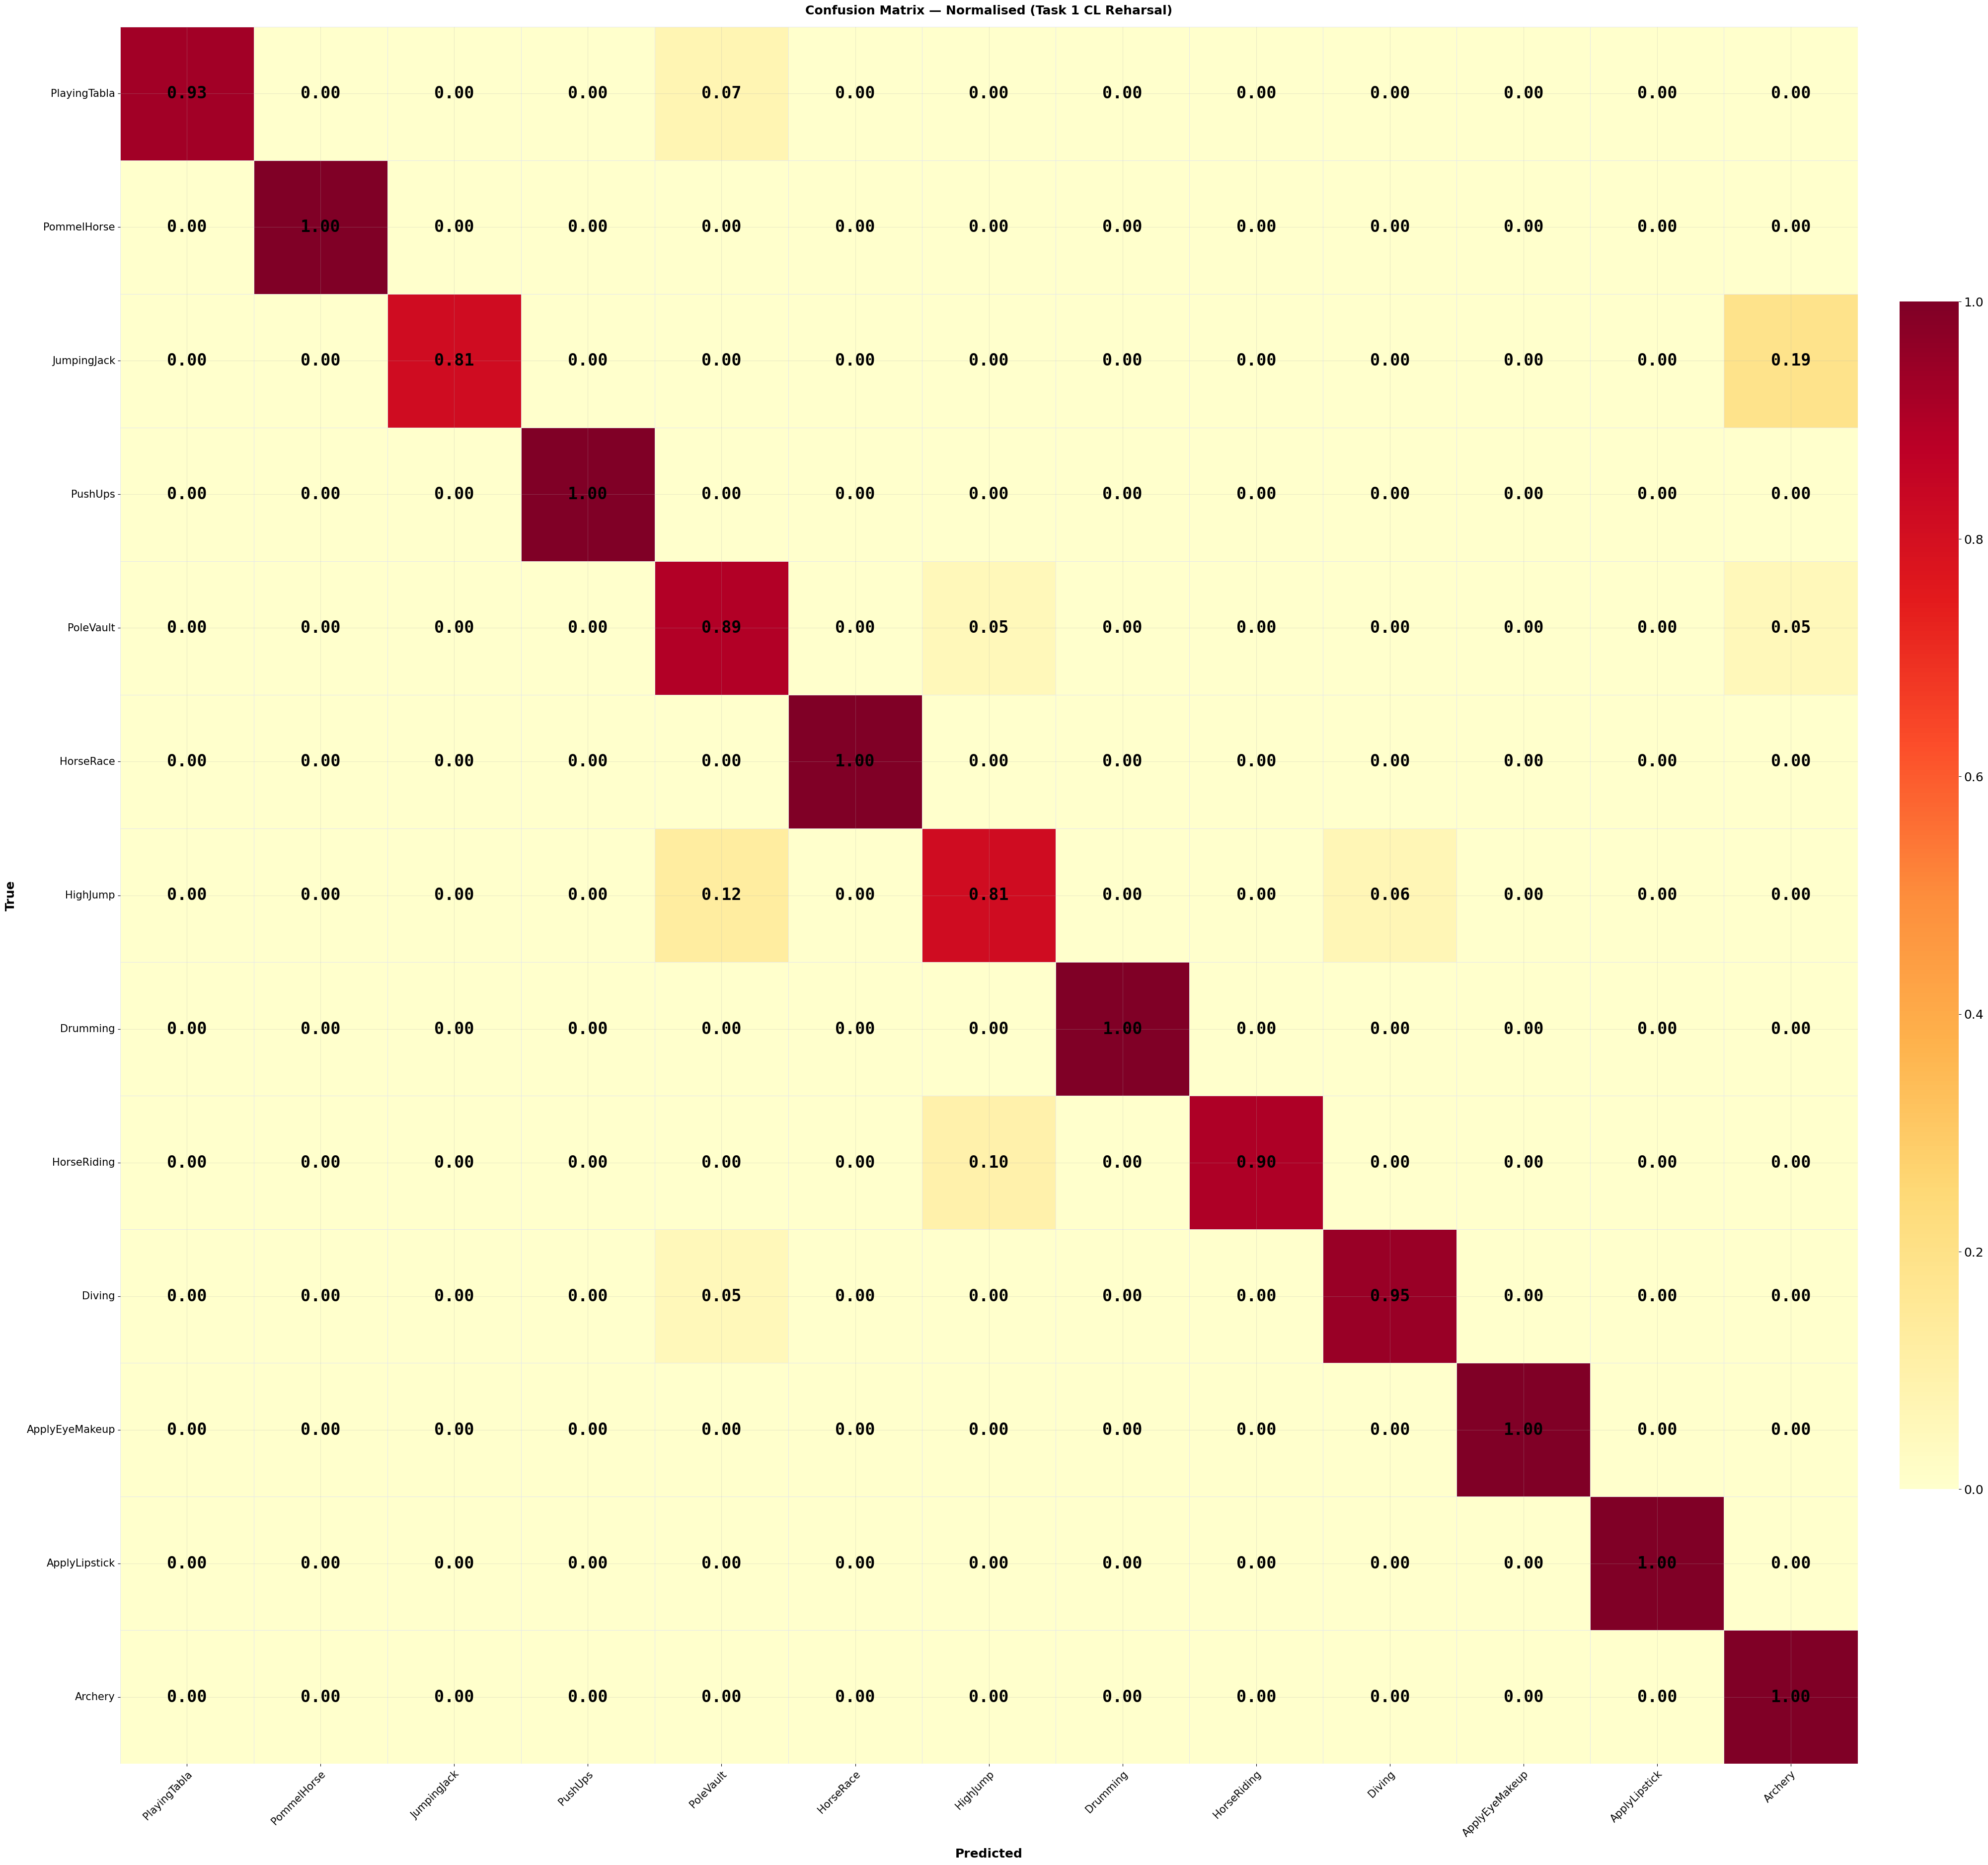

In [33]:
plot_confusion_matrix(all_labels_kd, all_preds_kd, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="Task 1 CL Reharsal")

#### Subset 2

In [34]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

# Global mapping
class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(class_to_idx)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BoxingPunchingBag': 13, 'BoxingSpeedBag': 14, 'BrushingTeeth': 15}


In [35]:
# Add samples from subset1 to the memory buffer (only 20 samples per class)
filler_loader = torch.utils.data.DataLoader(train_limited_sub1, batch_size=cfg.BATCH_SIZE)

for x, y in filler_loader:
    # This fills the buffer with 20 samples per old class
    buffer.add_batch(x, y)

print(f"Buffer populated with {len(buffer.data)} old samples.")

Buffer populated with 65 old samples.


In [36]:
# The former student becomes the new teacher
teacher = copy.deepcopy(student)
teacher = expand_classifier(student, len(ALL_CLASSES_LIST)).to(device)

# Expand the student to match old classes + new classes
student = expand_classifier(student, len(ALL_CLASSES_LIST)).to(device)

In [37]:
# Define the optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, student.parameters()),
    lr=cfg.REPLAY_LR
)

train_continual(
    model=student,
    teacher=teacher,
    train_loader=train_loader_sub2,  # new classes loader
    val_loader=combined_val_loader,
    replay_buffer=buffer,
    optimizer=optimizer,
    device=device,
    num_old_classes=len(cfg.SELECTED_CLASSES),
    lambda_distill=cfg.LAMBDA_DISTILL,
    epochs=cfg.REPLAY_EPOCHS,
    kd = True
)

Epoch 1/3 | Train Loss: 54.8865 | Val Loss: 24.6020 | Val Acc: 0.8321
Epoch 2/3 | Train Loss: 24.8776 | Val Loss: 21.8300 | Val Acc: 0.8358
Epoch 3/3 | Train Loss: 17.9477 | Val Loss: 23.3556 | Val Acc: 0.7948


In [38]:
# Evaluate the model over all tasks (only old classes, only new classes, both)
_ = evaluate_all_tasks(
    model=student,
    device=device,
    base_loader=test_loader_old,
    task_loaders=[test_loader_sub1, test_loader_sub2],
    combined_loaders=[combined_val_loader]
)

  base             -> Acc=0.8246  Loss=0.5935
  task1_only       -> Acc=0.5660  Loss=1.3217
  task2_only       -> Acc=0.9636  Loss=0.1783
  combined_t1      -> Acc=0.7948  Loss=0.6851


In [39]:
_, all_preds_kd_sub2, all_labels_kd_sub2 = test_model(student, combined_test_loader, device)

'''
print_detailed_metrics(
    all_labels=all_labels_kd,
    all_preds=all_preds_kd,
    num_classes=len(ALL_CLASSES_LIST),
    classes_list=ALL_CLASSES_LIST,
    split_old=(0, len(cfg.SELECTED_CLASSES)),
    split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST))
)
'''

Running Inference on Test Set...


Test Accuracy: 0.8087


'\nprint_detailed_metrics(\n    all_labels=all_labels_kd,\n    all_preds=all_preds_kd,\n    num_classes=len(ALL_CLASSES_LIST),\n    classes_list=ALL_CLASSES_LIST,\n    split_old=(0, len(cfg.SELECTED_CLASSES)),\n    split_new=(len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST))\n)\n'

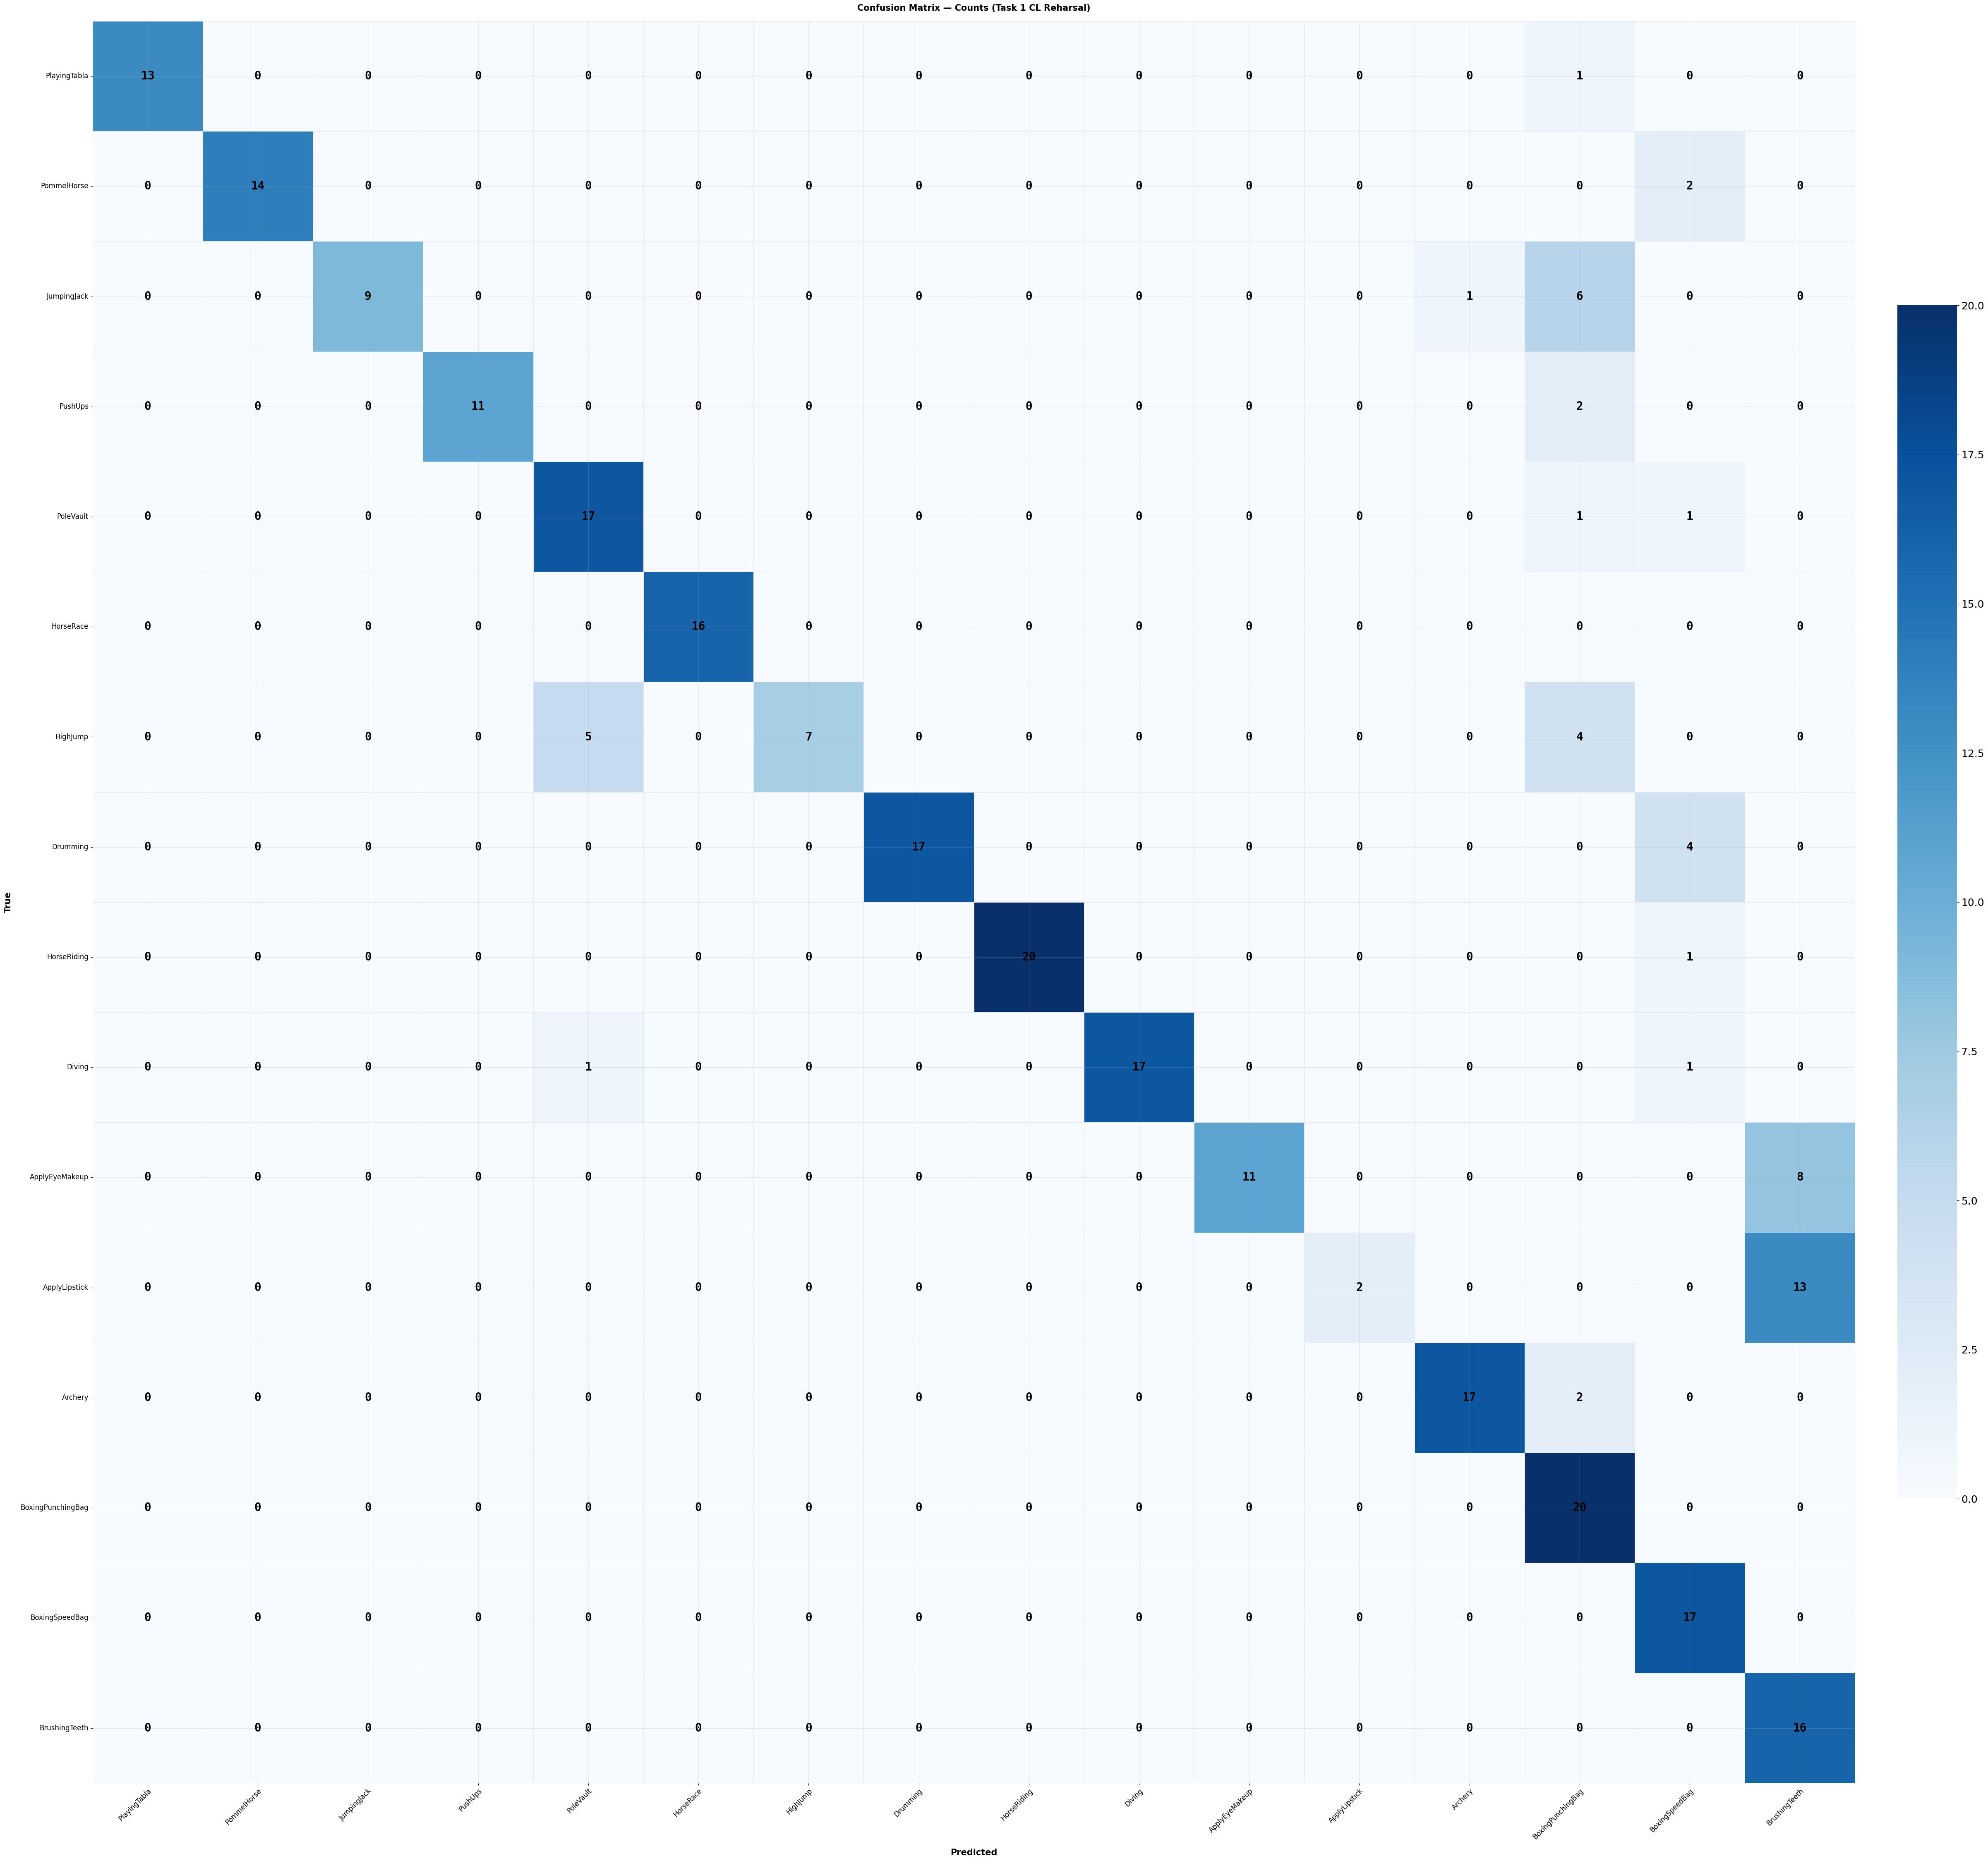

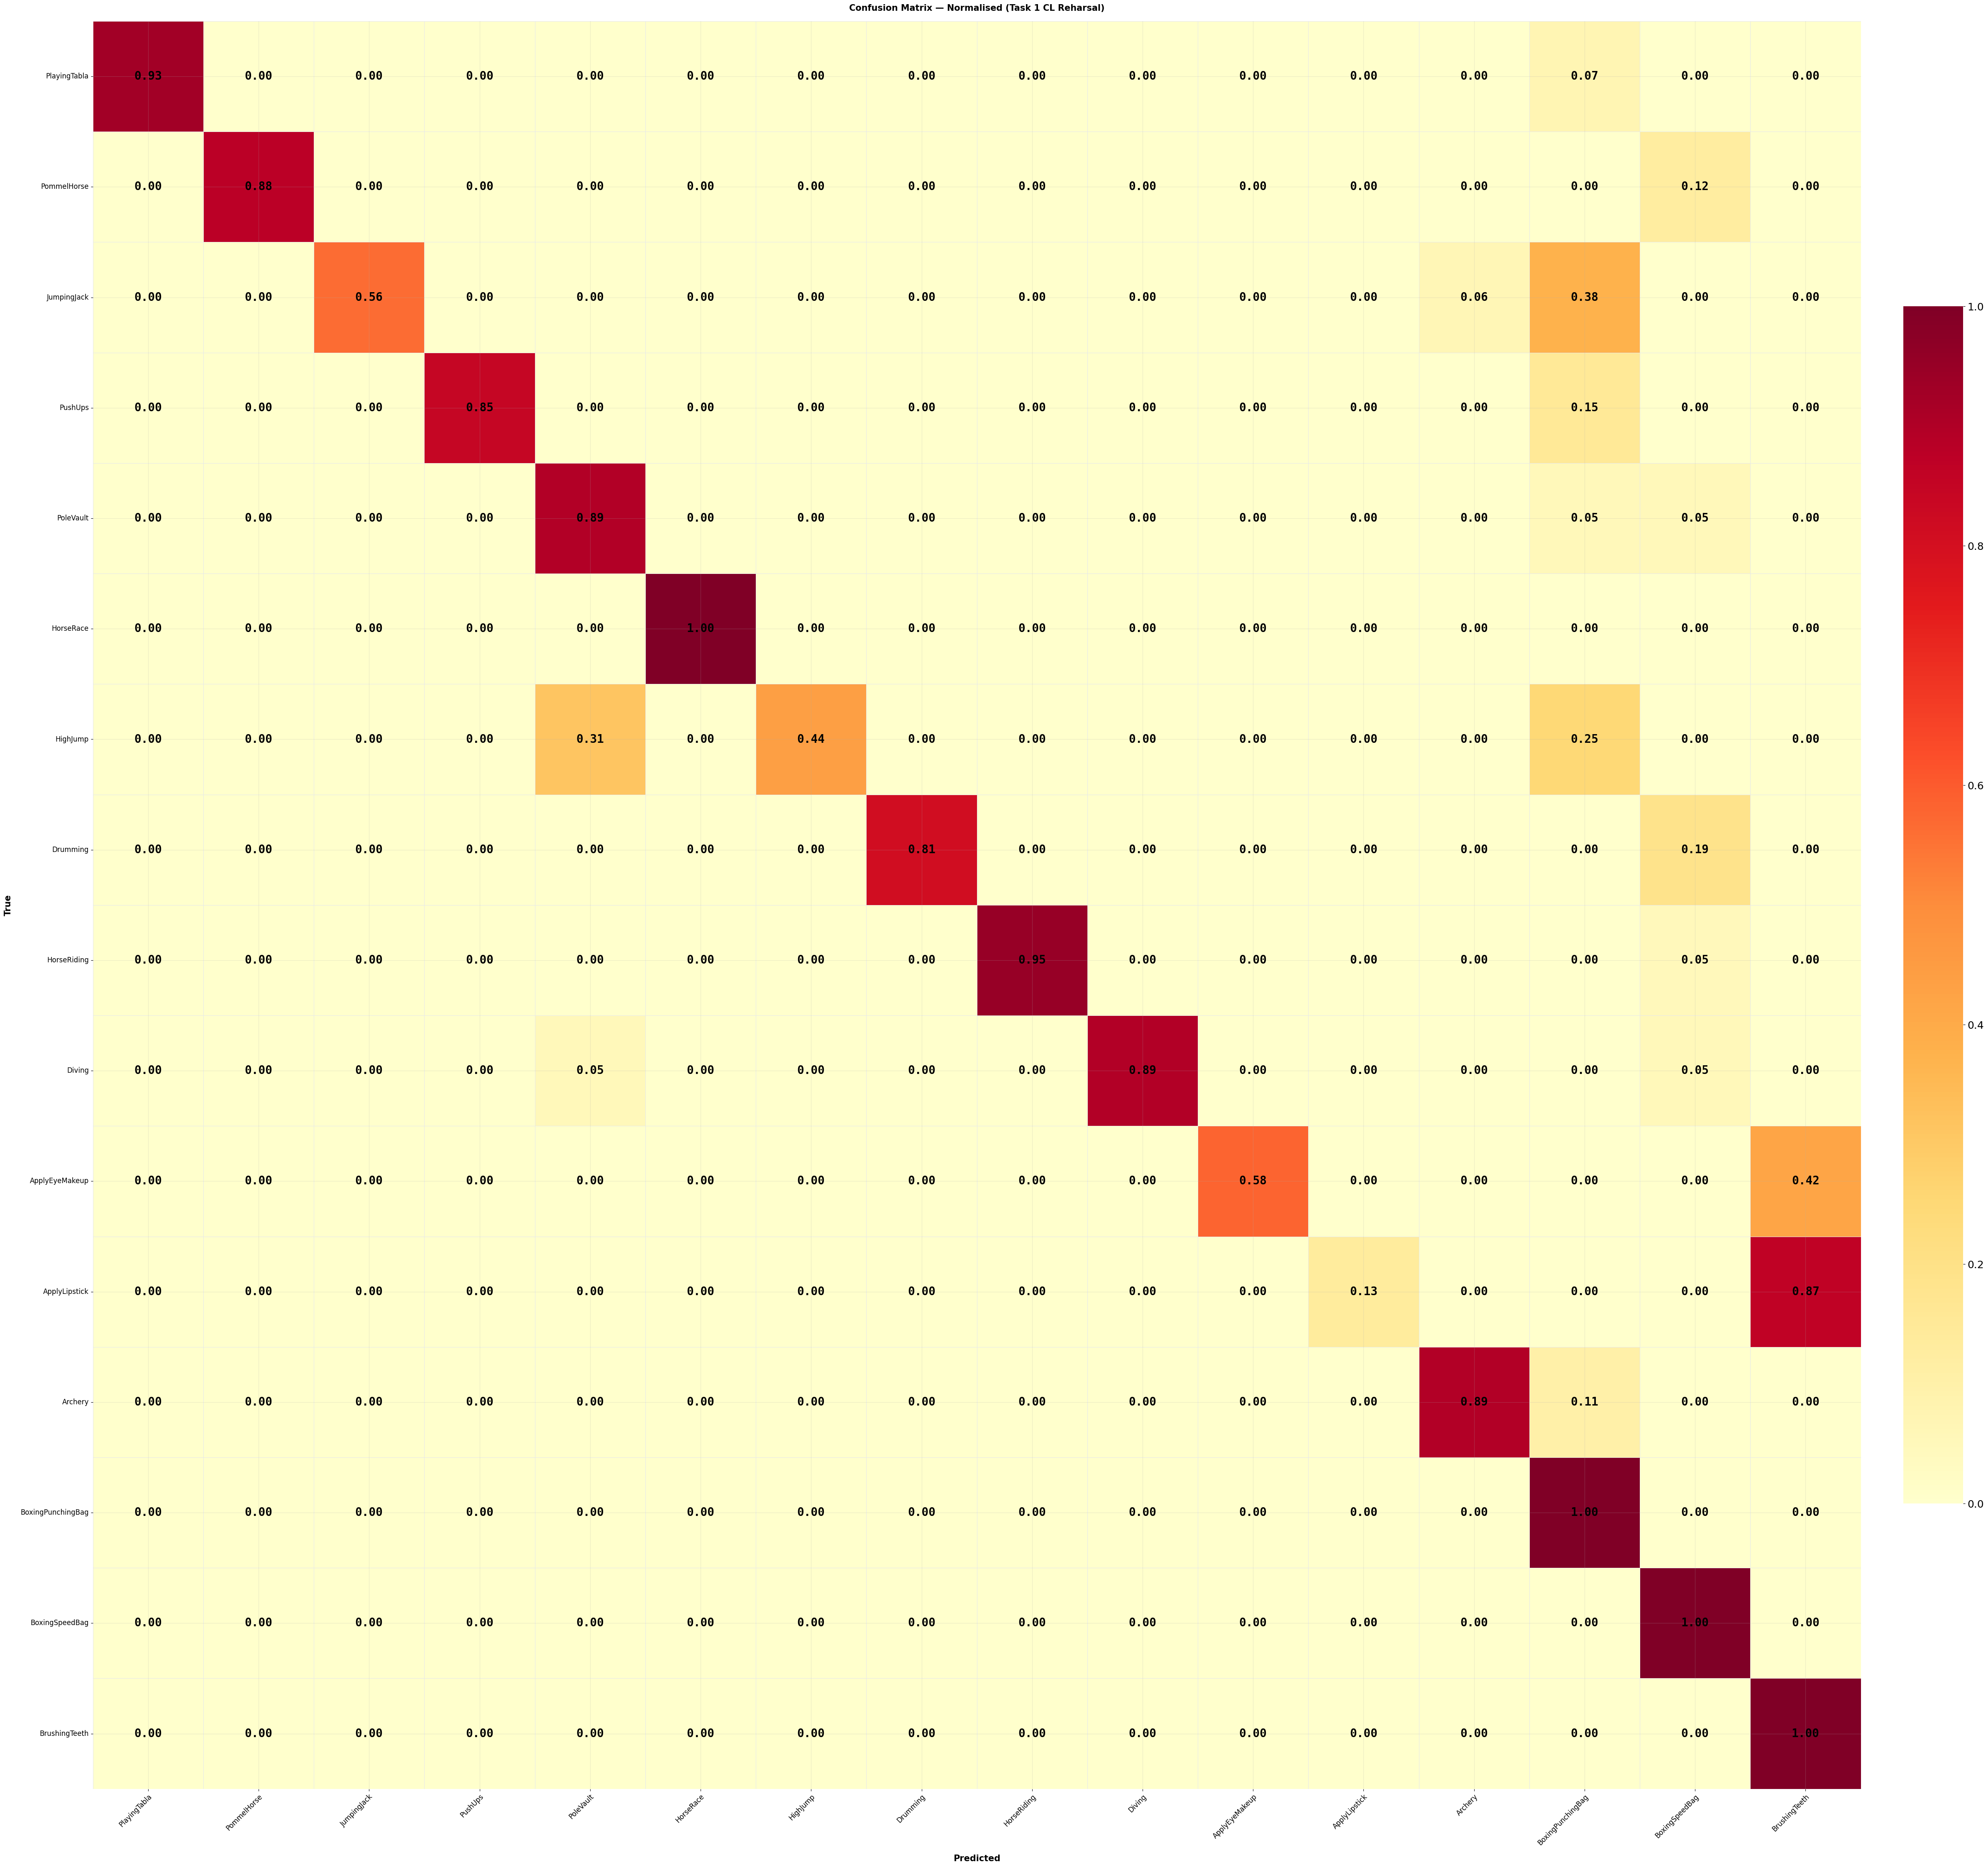

In [40]:
plot_confusion_matrix(all_labels_kd_sub2, all_preds_kd_sub2, num_classes=len(ALL_CLASSES_LIST), classes_list=ALL_CLASSES_LIST, name="Task 1 CL Reharsal")